# 1. Dataset Overview

This project uses the [Food-101 dataset](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/) from the paper [Food 101 - Mining Discriminative Components with Random Forests](https://link.springer.com/chapter/10.1007/978-3-319-10599-4_29) Lukas Bossard, Matthieu Guillaumin and Luc Van Gool published in the Computer Vision -- ECCV 2014 conference paper.

This dataset contains 101 food categories with 1,000 images each for a total of 101,000 images. 
- The dataset is officially split by 750 training and 250 test images per class.
- The test images are manually reviewed (**clean**)
- The training images are not manually reviewed (**unclean**) with wrong labels, bad crops, and certain photos contaning several dishes.
- I'm pretty sure I also saw a baby labeled as "chicken curry" so there are a lot of challenges for any potential CNN to overcome.


## 1.1 Load dataset and print basic info

In [1]:
%load_ext autoreload
%autoreload 2

# import libraries + functions & classes from train
import torch, random
from torch.utils.data import DataLoader, Subset
from pathlib import Path
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt

from train import (DeepCNN, CompactImageFolder, load_official_split,
                   download_food_dataset, pre_resize_dataset)

MEAN, STD = [0.5576, 0.4423, 0.327], [0.2591, 0.263, 0.2656]

In [2]:
# return immediately if dataset already on disk
download_food_dataset()
PATH = pre_resize_dataset()

# Caches the scanned file list so kernel restarts don't rewalk 101k files.
# Path.home() keeps this working on both machines
CACHE = str(Path.home() / "Documents" / "ml-runs")

dataset = CompactImageFolder(root=PATH, transform=transforms.ToTensor(), cache_dir=CACHE)
tr_idx, va_idx, te_idx = load_official_split(dataset, PATH)

dataset found
scaled dataset found
train 68175 | val 7575 | test 25250


In [3]:
# Verify the split rather than trusting it -- if these counts are wrong,
# load_official_split has a bug and every number downstream is meaningless.
counts = np.bincount(dataset.targets)

print(f"classes      : {len(dataset.classes)}")
print(f"total images : {len(dataset):,}")
print(f"per class    : min {counts.min()}, max {counts.max()}")
print(f"train        : {len(tr_idx):,}")
print(f"val          : {len(va_idx):,}    (10% of noisy training data carved out)")
print(f"test         : {len(te_idx):,}   (official, manually reviewed)")
print(f"\nfirst 8 classes: {', '.join(dataset.classes[:8])}")

classes      : 101
total images : 101,000
per class    : min 1000, max 1000
train        : 68,175
val          : 7,575    (10% of noisy training data carved out)
test         : 25,250   (official, manually reviewed)

first 8 classes: apple_pie, baby_back_ribs, baklava, beef_carpaccio, beef_tartare, beet_salad, beignets, bibimbap


## 1.2 Measure Mean/STD for Normalization (do not run unless needed)

In [ ]:
# run once to produce the MEAN/STD
stat_tfm = transforms.Compose([transforms.Resize(256),
                               transforms.CenterCrop(224),
                               transforms.ToTensor()])
raw = CompactImageFolder(root=path, transform=stat_tfm)


stat_loader = DataLoader(Subset(raw, tr_idx), batch_size=256, num_workers=0)
channel_sum, channel_sq_sum, count = torch.zeros(3), torch.zeros(3), 0
for images, _ in stat_loader:
    b = images.shape[0]
    pixels = images.view(b, 3, -1)          # (b,3,H,W) -> (b,3,H*W)
    channel_sum    += pixels.mean(2).sum(0)
    channel_sq_sum += (pixels ** 2).mean(2).sum(0)
    count          += b
mean = channel_sum / count
std  = (channel_sq_sum / count - mean ** 2).sqrt()   # sqrt(E[x^2] - E[x]^2)
print("MEAN =", [round(v, 4) for v in mean.tolist()])
print("STD  =", [round(v, 4) for v in std.tolist()])

MEAN = [0.5576, 0.4423, 0.327]
STD  = [0.2591, 0.263, 0.2656]


## 1.3 Display subset of batch

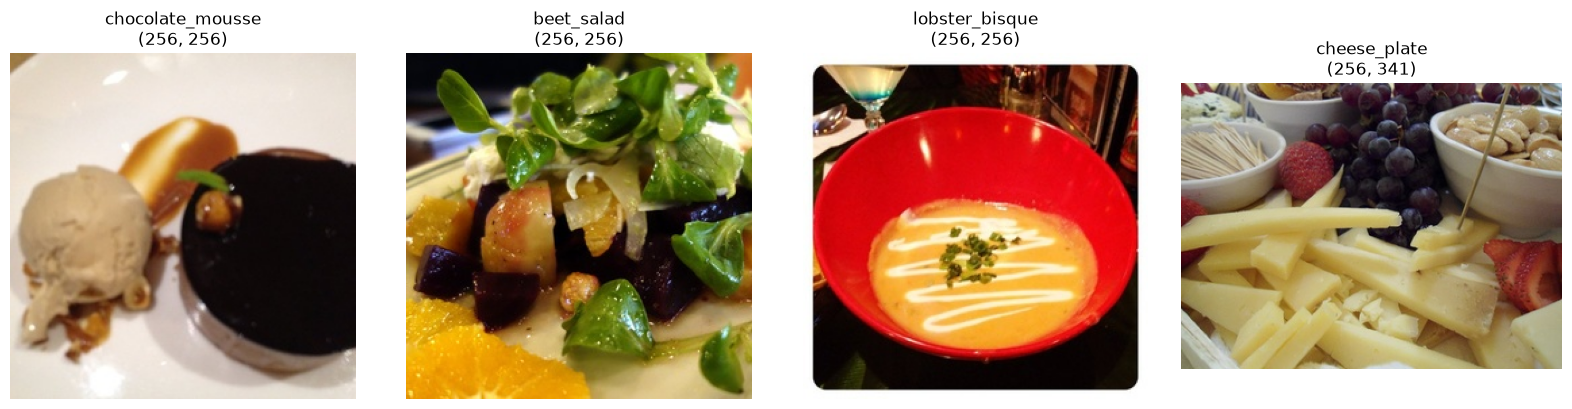

In [4]:
# pick indices of 4 random images
picks = random.sample(range(len(dataset)), 4)

fig, ax = plt.subplots(ncols=4, figsize=(16, 4))
for a, i in zip(ax, picks):
    img, label = dataset[i]                 
    a.imshow(img.permute(1, 2, 0))          # (C,H,W) -> (H,W,C) for matplotlib
    a.set_title(f"{dataset.classes[label]}\n{tuple(img.shape[1:])}")
    a.axis("off")
plt.tight_layout()

## 1.4 Augmentation Preview

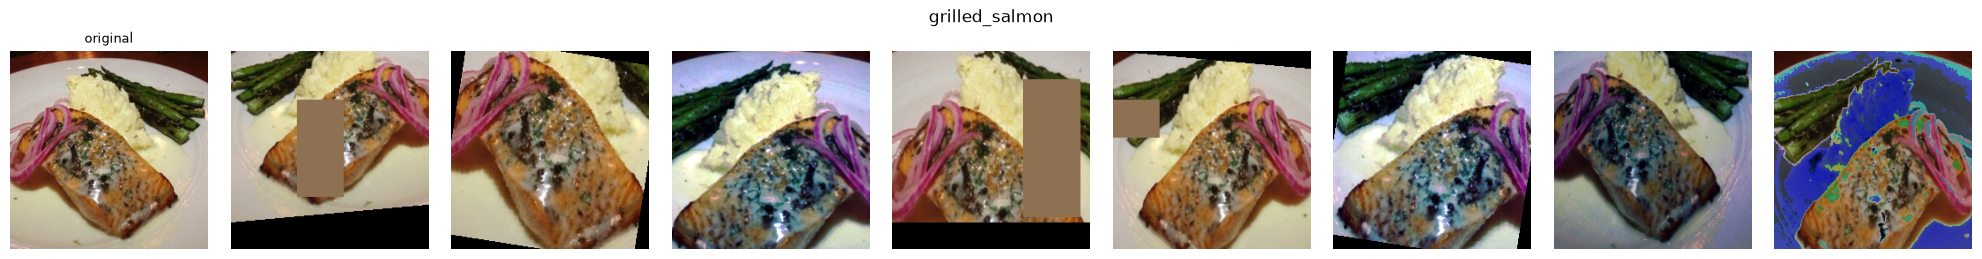

In [5]:
from train import build_transforms
from PIL import Image

train_tfm, eval_tfm = build_transforms(MEAN, STD)
mean_t, std_t = torch.tensor(MEAN).view(3,1,1), torch.tensor(STD).view(3,1,1)

i = random.Random(0).randrange(len(dataset))
t = int(dataset.targets[i])
src = Path(PATH) / dataset.classes[t] / dataset.fnames[i].decode()

fig, ax = plt.subplots(1, 9, figsize=(20, 2.6))
ax[0].imshow(dataset[i][0].permute(1,2,0)); ax[0].set_title("original", fontsize=9)
for a in ax[1:]:
    with Image.open(src) as im:
        aug = train_tfm(im.convert("RGB"))
    a.imshow((aug * std_t + mean_t).permute(1,2,0).clip(0,1))   # undo Normalize
for a in ax: a.axis("off")
plt.suptitle(dataset.classes[t]); plt.tight_layout()

# 2. Training

Training occurs in `train.py`. 

I learned the hard way when I migrated from my Macbook to my Windows PC (to take advantage of my Desktop GPU) that parallel data-loading was a headache on Windows.

Loading data in parallel (for speed) requires helper processes. While Unix systems can copy an existing process, Windows can't, so it has to start up an empty process and rebuild using the setup code. For a notebook, its classes live only in the kernel's memory, so there is no source file for a worker to re-import. The workers then die during startup, causing the main process to wait. This makes the training hang forever.

To alleviate this, each new process needs a guard in the setup code that tells it which specific parts are meant to be re-run. Notebooks have no place to put that guard, so setting `num_workers` above 0 on Windows causes the hang. `.py` scripts have this guard in the form of the `if __name__ == "__main__":` block, which only runs in the main process and in none of the helpers.

# 3. Results

TBA

Class names dump for web app

In [28]:
import json
from pathlib import Path

out = Path.cwd() / "classes.json"
with open(out, "w") as f:
    json.dump(dataset.classes, f, indent=2)
print(f"wrote {len(dataset.classes)} classes to {out}")

wrote 101 classes to c:\Users\nimav\OneDrive\Documents\github\image-classifier-CNN\classes.json
